<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 171.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 192.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 160.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 149.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 166.6 MB/s eta 0:00:00


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


/tmp/ipykernel_299/3987726837.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_counts.index, y=industry_counts.values, palette='viridis')


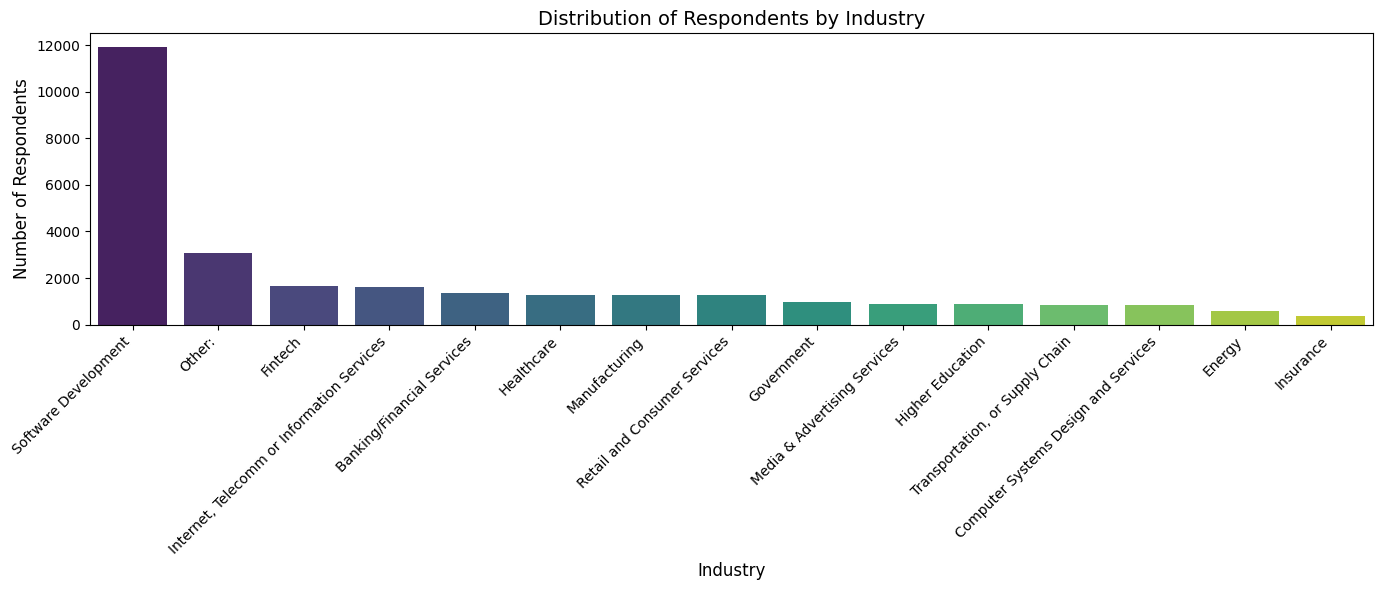

Top 5 Industries by Respondent Count:
Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Name: count, dtype: int64

Total Industries: 15
Most represented industry: Software Development (11918 respondents)


In [6]:
##Write your code here
industry_counts = df['Industry'].value_counts()

# Plot bar chart
plt.figure(figsize=(14, 6))
sns.barplot(x=industry_counts.index, y=industry_counts.values, palette='viridis')
plt.title('Distribution of Respondents by Industry', fontsize=14)
plt.xlabel('Industry', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Notable trends
print('Top 5 Industries by Respondent Count:')
print(industry_counts.head())
print(f'\nTotal Industries: {len(industry_counts)}')
print(f'Most represented industry: {industry_counts.idxmax()} ({industry_counts.max()} respondents)')


<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [8]:
##Write your code here
comp = df['ConvertedCompYearly'].dropna()

mean_comp   = comp.mean()
median_comp = comp.median()
std_comp    = comp.std()
print(f'Mean Compensation   : ${mean_comp:,.2f}')
print(f'Median Compensation : ${median_comp:,.2f}')
print(f'Std Deviation       : ${std_comp:,.2f}')

# Threshold: 3 standard deviations above the mean
threshold = mean_comp + 3 * std_comp
print(f'\nOutlier Threshold (mean + 3*std): ${threshold:,.2f}')

# Identify high compensation outliers
high_outliers = df[df['ConvertedCompYearly'] > threshold]
print(f'Number of high compensation outliers: {len(high_outliers)}')
print('\nSample of high earners:')
print(high_outliers[['ConvertedCompYearly']].head(10))

Mean Compensation   : $86,155.29
Median Compensation : $65,000.00
Std Deviation       : $186,756.97

Outlier Threshold (mean + 3*std): $646,426.21
Number of high compensation outliers: 89

Sample of high earners:
      ConvertedCompYearly
529              650000.0
828             1000000.0
1932             945000.0
2171             750000.0
2187            2000000.0
2316            1000000.0
2592             800000.0
3024            1302817.0
5934            1031099.0
6735             650000.0


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1 (25th percentile): $32,712.00
Q3 (75th percentile): $107,971.50
IQR                 : $75,259.50

Lower Bound: $-80,177.25
Upper Bound: $220,860.75

Total Outliers Detected (IQR method): 978


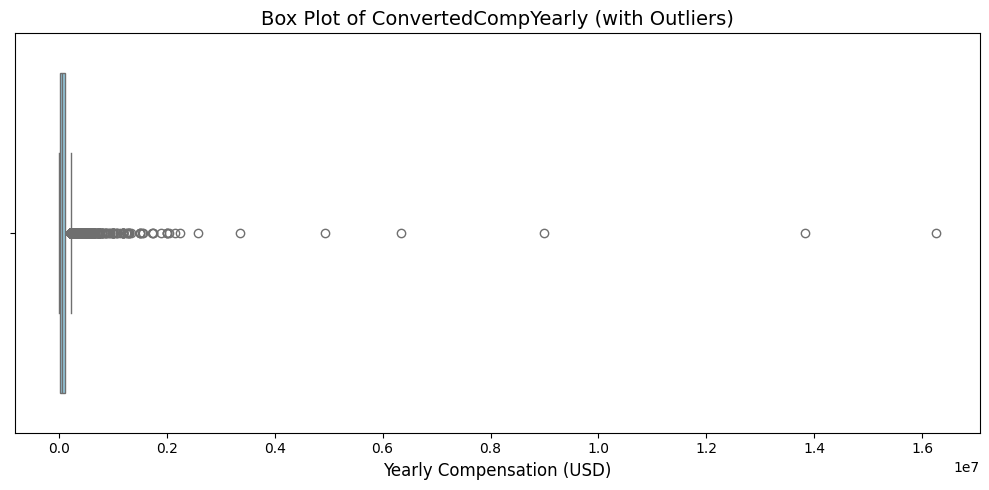

In [9]:
##Write your code here
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1 (25th percentile): ${Q1:,.2f}')
print(f'Q3 (75th percentile): ${Q3:,.2f}')
print(f'IQR                 : ${IQR:,.2f}')

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'\nLower Bound: ${lower_bound:,.2f}')
print(f'Upper Bound: ${upper_bound:,.2f}')

# Count outliers
outliers = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]
print(f'\nTotal Outliers Detected (IQR method): {len(outliers)}')

# Visualize with box plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['ConvertedCompYearly'], color='skyblue')
plt.title('Box Plot of ConvertedCompYearly (with Outliers)', fontsize=14)
plt.xlabel('Yearly Compensation (USD)', fontsize=12)
plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


Original DataFrame size : 65,437 rows
Cleaned DataFrame size  : 22,457 rows
Rows removed            : 42,980


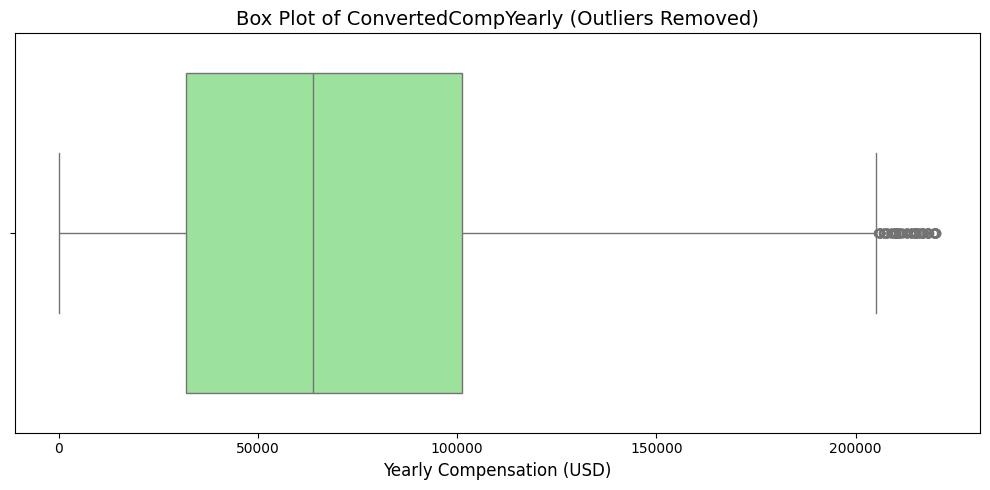


Cleaned Compensation Stats:
count     22457.000000
mean      71347.201897
std       51271.396445
min           1.000000
25%       32000.000000
50%       63694.000000
75%      101281.000000
max      220207.000000
Name: ConvertedCompYearly, dtype: float64


In [10]:
##Write your code here
df_clean = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

print(f'Original DataFrame size : {len(df):,} rows')
print(f'Cleaned DataFrame size  : {len(df_clean):,} rows')
print(f'Rows removed            : {len(df) - len(df_clean):,}')

# Visualize cleaned distribution
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['ConvertedCompYearly'], color='lightgreen')
plt.title('Box Plot of ConvertedCompYearly (Outliers Removed)', fontsize=14)
plt.xlabel('Yearly Compensation (USD)', fontsize=12)
plt.tight_layout()
plt.show()

print('\nCleaned Compensation Stats:')
print(df_clean['ConvertedCompYearly'].describe())

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


Age mapping applied. Sample values:
                     Age  Age_Numeric
1373  Under 18 years old         16.0
72       18-24 years old         21.0
374      25-34 years old         30.0
379      35-44 years old         40.0
395      45-54 years old         50.0
409      55-64 years old         60.0
524    65 years or older         70.0

Numeric columns used: ['ResponseId', 'CompTotal', 'WorkExp', 'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat', 'Age_Numeric']

Correlation of Age_Numeric with other numeric variables:
Age_Numeric            1.000000
WorkExp                0.842952
ConvertedCompYearly    0.371643
JobSat                 0.067088
CompTotal             -0.021397
JobSatPoints_1        -0.038828
ResponseId            -0.040862
JobSatPoints_6        -0.051272
JobSatPoints_8        -0.051550
JobSatPoints_4        -0.070060
JobSatPo

Text(0.5, 1.0, 'Correlation Matrix of Numeric Variables')

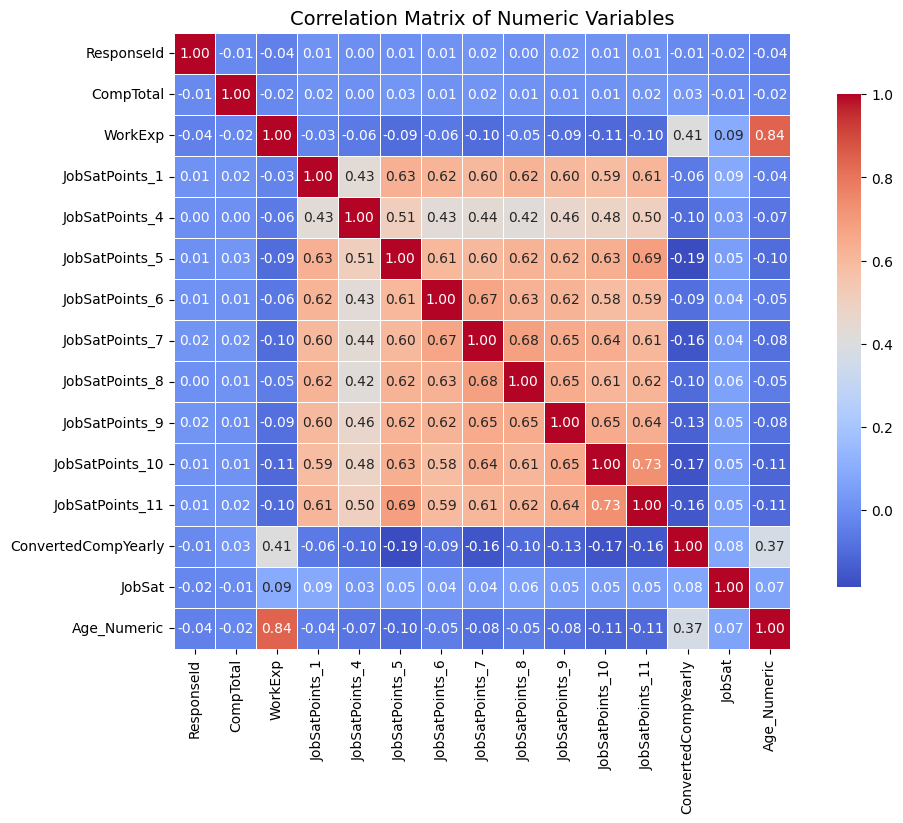

In [11]:
##Write your code here
# Map Age column to approximate numeric midpoint values
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': None
}

df_clean = df_clean.copy()
df_clean['Age_Numeric'] = df_clean['Age'].map(age_mapping)

print('Age mapping applied. Sample values:')
print(df_clean[['Age', 'Age_Numeric']].drop_duplicates().dropna().sort_values('Age_Numeric'))

# Select numeric columns for correlation
numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()
print(f'\nNumeric columns used: {numeric_cols}')

# Compute correlation matrix
corr_matrix = df_clean[numeric_cols].corr()

# Correlation of Age_Numeric with other variables
print('\nCorrelation of Age_Numeric with other numeric variables:')
print(corr_matrix['Age_Numeric'].sort_values(ascending=False))

# Visualize the full correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numeric Variables', fontsize=14)

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
